# Heatmaps of experimental data on network nodes

Bar charts (see the CKN tutorial) show one number per comparison. When the data has more
structure, e.g. treatments × time points, a small heatmap per node shows it better. This
tutorial makes such heatmaps with matplotlib, and shows them on the nodes in Cytoscape.

The data is the proteomics experiment of the CKN tutorial (case study 2 of the
[SKM publication](https://doi.org/10.1016/j.xplc.2024.100920)): logFC after 10 and 30
minutes of H₂O₂, with mock or LaCl₃ (Ca²⁺ channel inhibitor) pre-treatment. Each protein
gets a 2 × 2 heatmap, as in the publication:

|  | mock | LaCl₃ |
|---|---|---|
| **10 min** | logFC | logFC |
| **30 min** | logFC | logFC |

with significant changes (p < 0.05) marked by a star. The Cytoscape cells (the last section) need a running
Cytoscape; the heatmaps themselves are made without it.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

from skm_tools.annotations import get_nodes_by_mapman
from skm_tools.ckn import ckn_to_networkx, filter_ckn_edges, filter_ckn_nodes
from skm_tools.node_images import node_file_key
from skm_tools.paths import get_paths, path_subgraph

data_dir = Path("data")
output_dir = Path("output")
heatmap_dir = output_dir / "heatmaps"
heatmap_dir.mkdir(parents=True, exist_ok=True)

# show the messages of the skm-tools functions (e.g. what a filter removed)
logging.basicConfig(level="INFO", format="%(levelname)s %(name)s: %(message)s")

proteomics_file = Path("../publication/case-study-2/data/merged-proteomics-data.tsv")

## The network

The paths from Ca²⁺-related genes to the proteins that changed most, as in the CKN
tutorial (see there for the details).

<div class="alert alert-info">

**A subset, to keep this tutorial fast:** the 10 responsive proteins with the largest
change after 10 minutes, instead of all of them.

</div>

In [2]:
ckn = ckn_to_networkx(data_dir=data_dir)
filter_ckn_nodes(ckn, species=["ath"], tissues=["leaf", "not assigned"])
filter_ckn_edges(ckn, keep_edge_ranks=[0, 1, 2])

proteomics = pd.read_csv(proteomics_file, sep="\t", index_col=0)
responsive = [p for p in proteomics.index[proteomics["responsiveness"].notna()] if p in ckn]
targets = (proteomics.loc[responsive, "Mock|Mock vs Mock|H2O2 (10 min) log-FC"].abs()
           .sort_values(ascending=False).index[:10].tolist())

paths = get_paths(ckn, get_nodes_by_mapman(ckn, "27.8"), targets, shortest_overall=True)
net = path_subgraph(ckn, paths)
print(net)

INFO skm_tools.ckn: Removed 1849 nodes from the network.


INFO skm_tools.ckn: Removed 724551 edges and 11849 nodes from the network.


DiGraph with 89 nodes and 119 edges


## The data of a node, as a matrix

For each protein, the logFC and the p-values as 2 × 2 matrices: rows are the time
points, columns the pre-treatments.

In [3]:
TIMES = ["10 min", "30 min"]
TREATMENTS = {"mock": "Mock|Mock vs Mock|H2O2", "LaCl₃": "La3+|Mock vs La3+|H2O2"}


def matrices(protein, times=TIMES):
    """(logFC, p-value) as arrays: rows 0m0.000s 0m0.000s
0m0.000s 0m0.000s, columns TREATMENTS."""
    row = proteomics.loc[protein]
    logfc = np.array([[row[f"{t} ({time}) log-FC"] for t in TREATMENTS.values()] for time in times],
                     dtype=float)
    pvalue = np.array([[row[f"{t} ({time}) p-value"] for t in TREATMENTS.values()] for time in times],
                      dtype=float)
    return logfc, pvalue


matrices(targets[0])

(array([[ 3.21794, -0.39206],
        [ 0.5498 , -0.19762]]),
 array([[1.e-05,    nan],
        [   nan,    nan]]))

## Drawing a heatmap

As in the publication: a blue-white-red colour map from logFC -1 to 1 (the same scale for
all nodes; stronger changes get the end colours), missing values in grey, thick black
borders, and a white star on significant changes (p < 0.05). The images have no axes,
as they are shown next to the nodes; the legend is made separately.

In [4]:
CMAP = plt.get_cmap("bwr").with_extremes(bad="lightgrey")
NORM = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
P_CUTOFF = 0.05


def draw_heatmap(ax, protein, star_size=30, line_width=4, times=TIMES):
    logfc, pvalue = matrices(protein, times)
    ax.pcolormesh(np.ma.masked_invalid(logfc), cmap=CMAP, norm=NORM, edgecolors="black",
                  linewidth=line_width)
    for row, col in zip(*np.nonzero(pvalue < P_CUTOFF)):
        # marker (6, 2, 0): a six-pointed star (asterisk)
        ax.plot(col + 0.5, row + 0.5, marker=(6, 2, 0), markersize=star_size,
                markeredgecolor="white", markeredgewidth=star_size / 6)
    ax.invert_yaxis()  # 10 min on top
    ax.set_aspect("equal")
    ax.axis("off")


def save_heatmap(protein, path, times=TIMES):
    fig, ax = plt.subplots()
    draw_heatmap(ax, protein, times=times)
    fig.savefig(path, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

The heatmaps of the targets, with their names, and the legend:

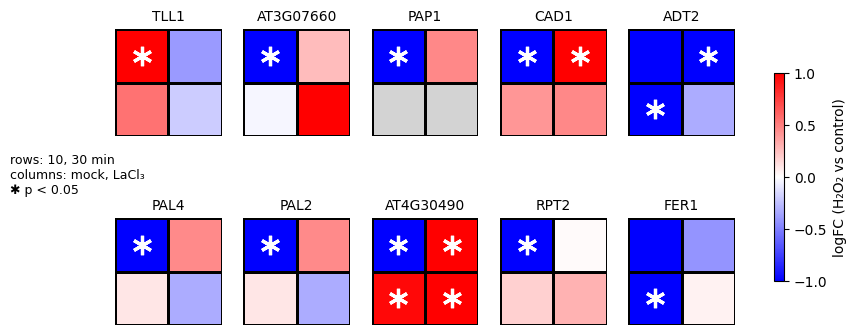

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
label = dict(net.nodes(data="display_label"))
for ax, protein in zip(axes.flat, targets):
    draw_heatmap(ax, protein, star_size=14, line_width=2)
    ax.set_title(label[protein], fontsize=10)

colourbar = fig.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=CMAP), ax=axes, shrink=0.6,
                         label="logFC (H₂O₂ vs control)")
fig.text(0.02, 0.5, "rows: 10, 30 min\ncolumns: mock, LaCl₃\n✱ p < 0.05", va="center", fontsize=9)
plt.show()

## One image per node

The image files are named after the nodes, so that they can be matched to the nodes in
Cytoscape: `node_file_key` turns a node name into a file name (the gene ids here stay as
they are). Only the nodes with data get an image.

In [6]:
with_data = [n for n in net if n in proteomics.index]
for protein in with_data:
    save_heatmap(protein, heatmap_dir / f"{node_file_key(protein)}.png")
assert len(list(heatmap_dir.glob("*.png"))) >= len(with_data)
print(len(with_data), "heatmaps in", heatmap_dir)

31 heatmaps in output/heatmaps


## Cytoscape

The rest of this tutorial needs a running Cytoscape (3.10 or later) and the `cytoscape` extra
(`pip install "skm-tools[cytoscape]"`). We load the network with the SKM style, load the
image locations into a node table column, and show that column below the nodes in a copy
of the style.

Cytoscape caches images, and can show an old image after a file has changed. With
`unique_dir`, `load_node_images` first copies the images to new, unique file names, so
Cytoscape always loads them fresh.

In [7]:
# ci-skip: needs a running Cytoscape
import py4cytoscape as p4c
from IPython.display import Image

from skm_tools import cytoscape_utils as cu

p4c.cytoscape_ping()

DEBUG py4...: Calling cytoscape_ping()


DEBUG py4...: ǀCalling cytoscape_version_info(base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('version', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: Attempting to direct connect to Cytoscape on http://127.0.0.1:1234/v1


DEBUG py4...: Detected py4cytoscape running on Cytoscape workstation


...

DEBUG py4...: ǀǀReturning 'cyrest_get': {'apiVersion': 'v1', 'cytoscapeVersion': '3.10.2'}


DEBUG py4...: ǀReturning 'cytoscape_version_info': {'apiVersion': 'v1', 'cytoscapeVersion': '3.10.2', 'automationAPIVersion': '1.13.0', 'py4cytoscapeVersion': '1.13.0'}


DEBUG py4...: Returning 'cytoscape_ping': 'You are connected to Cytoscape!'


DEBUG py4...: --------------------


'You are connected to Cytoscape!'

In [8]:
# ci-skip: needs a running Cytoscape
suid = cu.load_network(net, title="Ca2+ paths: heatmaps", collection="Tutorial: heatmaps", style="skm")
p4c.layout_network("force-directed", network=suid)

images = cu.match_files_to_nodes(heatmap_dir, net.nodes())
cu.load_node_images(images, "heatmap", network=suid, unique_dir=output_dir / "heatmaps-unique")

style = cu.copy_style("SKM", "SKM-heatmaps", networks=[suid], overwrite=True)
cu.show_node_images(style, "heatmap", position="below", size=50)

DEBUG py4...: Calling create_network_from_networkx(<networkx.classes.digraph.DiGraph object at 0x7fdebf7a1590>, title='Ca2+ paths: heatmaps', collection='Tutorial: heatmaps')


DEBUG py4...: ǀCalling create_network_from_data_frames(nodes=      node_type      locus_type species       TAIR display_label short_name  \
0   PlantCoding  protein_coding     ath  AT1G76040         CPK29      CPK29   
1   PlantCoding  protein_coding     ath  AT5G07070         CIPK2      CIPK2   
2   PlantCoding  protein_coding     ath  AT4G32570         TIFY8      TIFY8   
3   PlantCoding  protein_coding     ath  AT1G74740         CPK30      CPK30   
4   PlantCoding  protein_coding     ath  AT2G37040          PAL1       PAL1   
..          ...             ...     ...        ...           ...        ...   
84  PlantCoding  protein_coding     ath  AT5G61010       EXO70E2    EXO70E2   
85  PlantCoding  protein_coding     ath  AT5G60910          AGL8       AGL8   
86  PlantCoding  protein_coding     ath  AT1G15670         KFB01      KFB01   
87  PlantCoding  protein_coding     ath  AT5G65210          TGA1       TGA1   
88  PlantCoding  protein_coding     ath  AT5G15210          HB30      

DEBUG py4...: ǀǀCalling cyrest_post('networks', parameters={'title': 'Ca2+ paths: heatmaps', 'collection': 'Tutorial: heatmaps'}, body={'data': [{'name': 'Ca2+ paths: heatmaps'}], 'elements': {'nodes': [{'data': {'id': 'AT1G76040'}}, {'data': {'id': 'AT5G07070'}}, {'data': {'id': 'AT4G32570'}}, {'data': {'id': 'AT1G74740'}}, {'data': {'id': 'AT2G37040'}}, {'data': {'id': 'AT5G47100'}}, {'data': {'id': 'AT3G07630'}}, {'data': {'id': 'AT4G38810'}}, {'data': {'id': 'AT1G45201'}}, {'data': {'id': 'AT1G10940'}}, {'data': {'id': 'AT3G01280'}}, {'data': {'id': 'AT5G39670'}}, {'data': {'id': 'AT5G24270'}}, {'data': {'id': 'AT2G43290'}}, {'data': {'id': 'AT2G30360'}}, {'data': {'id': 'AT3G07660'}}, {'data': {'id': 'AT1G35160'}}, {'data': {'id': 'AT3G03000'}}, {'data': {'id': 'AT1G29690'}}, {'data': {'id': 'AT3G47620'}}, {'data': {'id': 'AT1G22920'}}, {'data': {'id': 'AT3G15170'}}, {'data': {'id': 'AT5G61850'}}, {'data': {'id': 'AT1G47870'}}, {'data': {'id': 'AT5G22630'}}, {'data': {'id': 'AT3G5

DEBUG py4...: ǀǀHTTP POST(http://127.0.0.1:1234/v1/networks), params: {'title': 'Ca2+ paths: heatmaps', 'collection': 'Tutorial: heatmaps'}, json: {'data': [{'name': 'Ca2+ paths: heatmaps'}], 'elements': {'nodes': [{'data': {'id': 'AT1G76040'}}, {'data': {'id': 'AT5G07070'}}, {'data': {'id': 'AT4G32570'}}, {'data': {'id': 'AT1G74740'}}, {'data': {'id': 'AT2G37040'}}, {'data': {'id': 'AT5G47100'}}, {'data': {'id': 'AT3G07630'}}, {'data': {'id': 'AT4G38810'}}, {'data': {'id': 'AT1G45201'}}, {'data': {'id': 'AT1G10940'}}, {'data': {'id': 'AT3G01280'}}, {'data': {'id': 'AT5G39670'}}, {'data': {'id': 'AT5G24270'}}, {'data': {'id': 'AT2G43290'}}, {'data': {'id': 'AT2G30360'}}, {'data': {'id': 'AT3G07660'}}, {'data': {'id': 'AT1G35160'}}, {'data': {'id': 'AT3G03000'}}, {'data': {'id': 'AT1G29690'}}, {'data': {'id': 'AT3G47620'}}, {'data': {'id': 'AT1G22920'}}, {'data': {'id': 'AT3G15170'}}, {'data': {'id': 'AT5G61850'}}, {'data': {'id': 'AT1G47870'}}, {'data': {'id': 'AT5G22630'}}, {'data': {

DEBUG py4...: ǀǀOK[200], content: {"networkSUID":12717}


...

DEBUG py4...: ǀHTTP PUT(http://127.0.0.1:1234/v1/styles/SKM-heatmaps/defaults), json: [{'visualProperty': 'NODE_CUSTOMGRAPHICS_SIZE_1', 'value': 50}]


DEBUG py4...: ǀOK[200], content: 


DEBUG py4...: ǀReturning 'cyrest_put': ''


DEBUG py4...: Returning 'set_visual_property_default': ''


DEBUG py4...: --------------------


DEBUG py4...: Calling fit_content(network=12717)


DEBUG py4...: ǀCalling get_network_view_suid(12717, base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('networks', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀHTTP GET(http://127.0.0.1:1234/v1/networks)


DEBUG py4...: ǀǀOK[200], content: [128,709,11094,555,268,11420,413,12717]


...

DEBUG py4...: ǀHTTP POST(http://127.0.0.1:1234/v1/commands/view/export%20png), json: {'allGraphicsDetails': 'True', 'Zoom': '150', 'outputFile': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-heatmaps.png', 'view': 'SUID:13609'}


DEBUG py4...: ǀOK[200], content: {
 "data": {"file":"/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-heatmaps.png"},
 "errors":[]
}


DEBUG py4...: ǀReturning 'commands_post': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-heatmaps.png'}


DEBUG py4...: Returning 'export_image': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/ckn-heatmaps.png'}


DEBUG py4...: --------------------


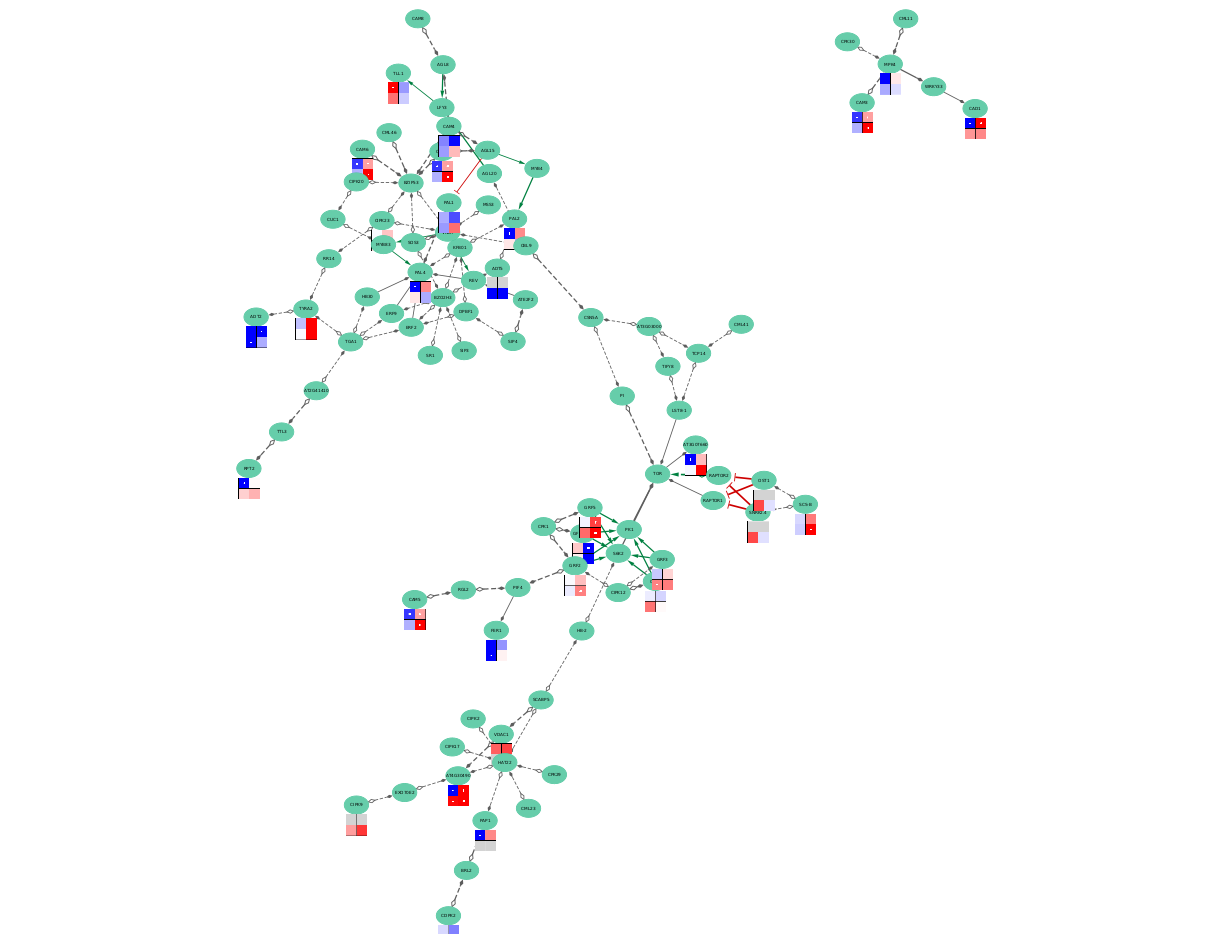

In [9]:
# ci-skip: needs a running Cytoscape
image = cu.export_network(output_dir / "ckn-heatmaps.png", format="PNG", zoom=150, network=suid)
Image(image)

### One network per time point

To compare conditions side by side, show each on its own copy of the network. Here, one
copy per time point, each showing that time point's row (mock, LaCl₃):

- `clone_network` copies the network, with its layout, into a new collection, which has
  its own node table: the copies can have different images in the same column;
- each copy gets its own copy of the style (`copy_style`), since `show_node_images` maps
  the column into a style, and a style is shared by all networks it is applied to;
- `export_collection` exports every network of a collection.

DEBUG py4...: Calling clone_network(network=12717)


DEBUG py4...: ǀCalling get_network_suid(12717, base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('networks', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀHTTP GET(http://127.0.0.1:1234/v1/networks)


DEBUG py4...: ǀǀOK[200], content: [128,709,11094,555,268,11420,413,12717]


...

DEBUG py4...: ǀHTTP POST(http://127.0.0.1:1234/v1/commands/view/export%20png), json: {'allGraphicsDetails': 'True', 'Zoom': '150', 'outputFile': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/heatmaps-per-time/Ca2_paths_30_min_15590.png', 'view': 'SUID:16524'}


DEBUG py4...: ǀOK[200], content: {
 "data": {"file":"/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/heatmaps-per-time/Ca2_paths_30_min_15590.png"},
 "errors":[]
}


DEBUG py4...: ǀReturning 'commands_post': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/heatmaps-per-time/Ca2_paths_30_min_15590.png'}


DEBUG py4...: Returning 'export_image': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/heatmaps-per-time/Ca2_paths_30_min_15590.png'}


DEBUG py4...: --------------------


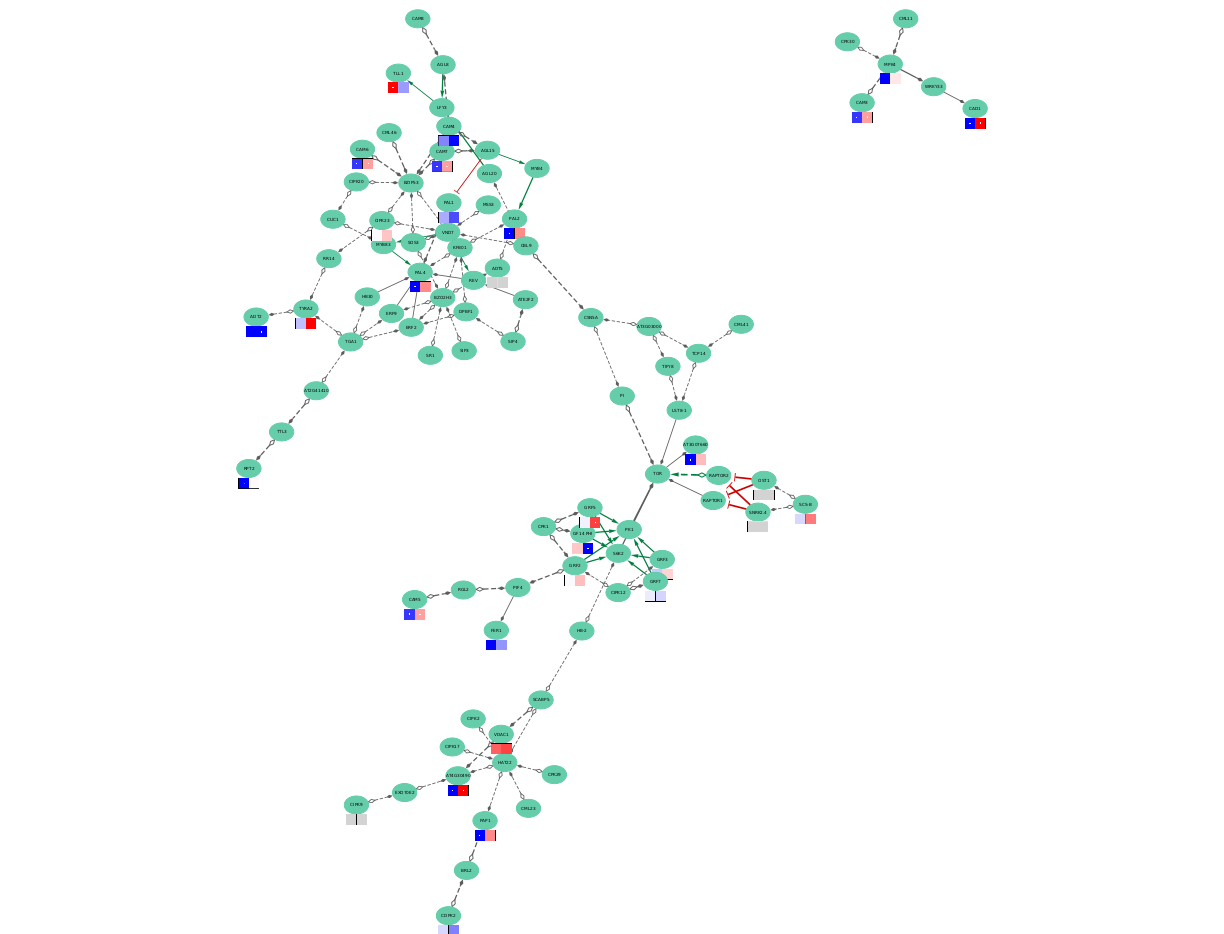

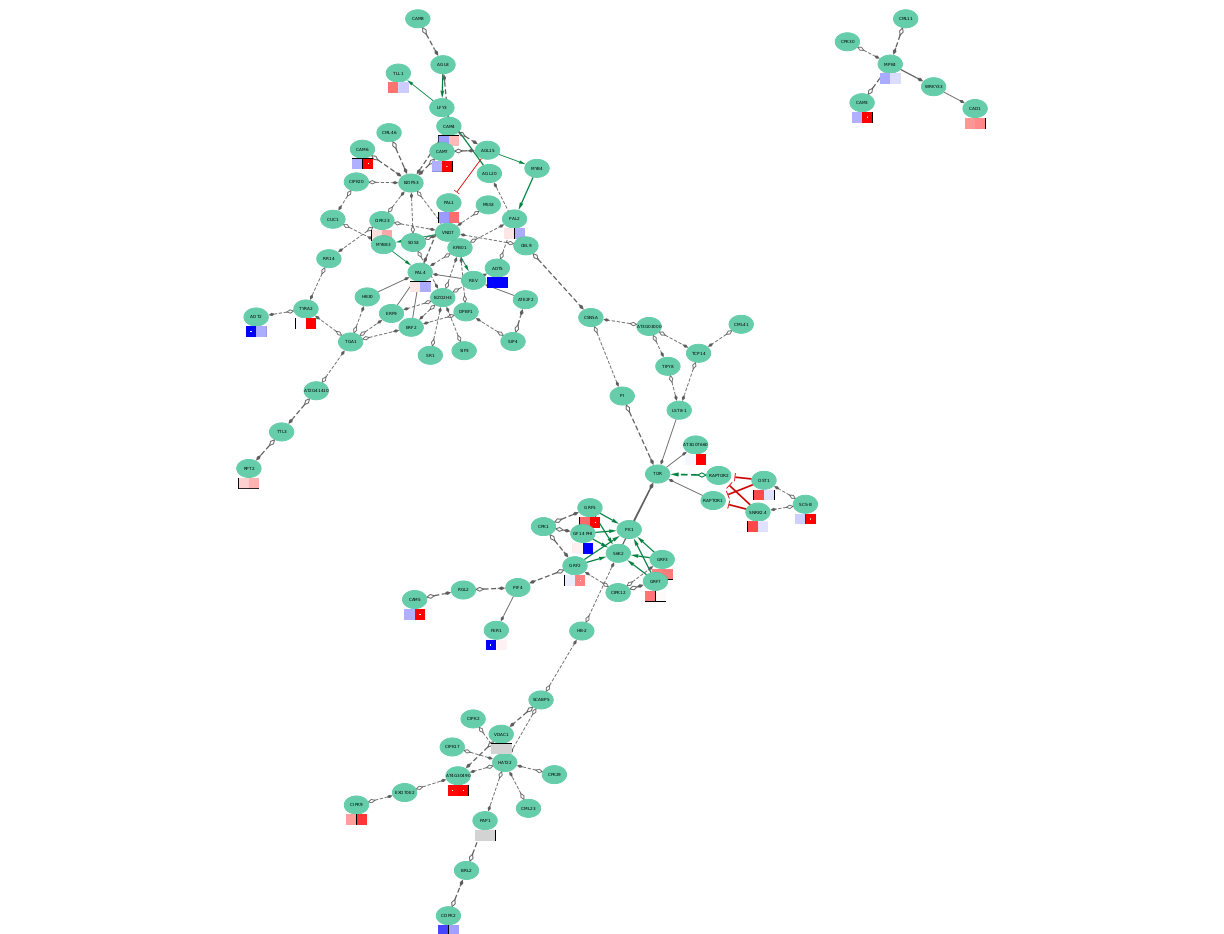

In [10]:
# ci-skip: needs a running Cytoscape
from IPython.display import display

exported = []
for time in TIMES:
    folder = heatmap_dir / time.replace(" ", "")
    folder.mkdir(exist_ok=True)
    for protein in with_data:
        save_heatmap(protein, folder / f"{node_file_key(protein)}.png", times=[time])

    clone = cu.clone_network(name=f"Ca2+ paths: {time}", collection=f"Tutorial: heatmaps, {time}",
                             network=suid)
    cu.load_node_images(cu.match_files_to_nodes(folder, net.nodes()), "heatmap", network=clone,
                        unique_dir=output_dir / "heatmaps-unique")
    clone_style = cu.copy_style("SKM", f"SKM-heatmaps {time}", networks=[clone], overwrite=True)
    cu.show_node_images(clone_style, "heatmap", position="below", size=50)
    exported += cu.export_collection(output_dir / "heatmaps-per-time", format="PNG", network=clone, zoom=150)

for image in exported:
    display(Image(image))